In [1]:
#CIS 5523 Reaserch Project:Using Text Mining to Classify Congressional Bills 
#By: Daniel Blitshtein

import re
from pathlib import Path

import pandas as pd
from pypdf import PdfReader
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS



# 1) Setting the pdf path

PDF_PATH = Path("BILLS-119hr1eh.pdf")   # change if needed
assert PDF_PATH.exists(), f"Could not find PDF at {PDF_PATH.resolve()}"

# 2) Now I can read the pdf page by page 

reader = PdfReader(str(PDF_PATH))

pages = []
for i, page in enumerate(reader.pages):
    text = page.extract_text() or ""
    pages.append({
        "page_num": i + 1,
        "text": text
    })

pages_df = pd.DataFrame(pages)
print(f"Pages read: {len(pages_df)}")



# 3) Cleaning out any RAW PDF TEXT

full_text = "\n\n".join(pages_df["text"].fillna("").tolist())

def clean_pdf_text(text: str) -> str:
    # This function Removes any decorative repeated markers that appears in congressional PDFs
    text = re.sub(r"•HR\s+\d+\s+EH\d*S?", " ", text)

   
    text = re.sub(r"(\w)-\s*\n\s*(\w)", r"\1\2", text)
    text = re.sub(r"\n{2,}", "\n\n", text)
    text = re.sub(r"(?<!\n)\n(?!\n)", " ", text)
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text)

    return text.strip()

clean_text = clean_pdf_text(full_text)

print("\nCLEAN TEXT PREVIEW:\n")
print(clean_text[:2000])



# 4) Removing the TOC Region(the title since it's not needed)

# The bill usually contains TITLE markers in the table of contents
# and again in the actual body. We try to start at the second TITLE occurrence.

title_hits = [m.start() for m in re.finditer(r"\bTITLE\s+[IVXLCDM]+\b", clean_text)]
print(f"\nFound TITLE markers: {len(title_hits)}")

candidate_idx = title_hits[1] if len(title_hits) > 1 else 0
working_text = clean_text[candidate_idx:].strip()

print("\nWORKING TEXT PREVIEW:\n")
print(working_text[:2000])


# 5) Looking for the congressional headings
# I split using this structure:
# TITLE -> Subtitle -> PART -> SUBPART -> SEC.

heading_pattern = re.compile(
    r"(?P<title>\bTITLE\s+[IVXLCDM]+\s*[—\-].*?)"
    r"|(?P<subtitle>\bSubtitle\s+[A-Z][—\-].*?)"
    r"|(?P<part>\bPART\s+\d+[—\-].*?)"
    r"|(?P<subpart>\bSUBPART\s+[A-Z][—\-].*?)"
    r"|(?P<section>\bSEC\.\s+\d+[A-Z\-]*\.\s+.*?)"
)

matches = list(heading_pattern.finditer(working_text))
print(f"\nHeading matches found: {len(matches)}")

for m in matches[:20]:
    print(m.lastgroup, "->", m.group(0)[:120])



# 6) Building out the strucutred section now

records = []

current_title = None
current_subtitle = None
current_part = None
current_subpart = None
current_section = None
section_start = None

def clean_heading(s):
    if s is None:
        return None
    s = s.strip()
    s = re.sub(r"\s+", " ", s)
    return s

for i, match in enumerate(matches):
    kind = match.lastgroup
    text = clean_heading(match.group(0))
    start = match.start()

    if kind == "title":
        current_title = text
        current_subtitle = None
        current_part = None
        current_subpart = None

    elif kind == "subtitle":
        current_subtitle = text
        current_part = None
        current_subpart = None

    elif kind == "part":
        current_part = text
        current_subpart = None

    elif kind == "subpart":
        current_subpart = text

    elif kind == "section":
        # Close the previous section before starting a new one
        if current_section is not None and section_start is not None:
            body = working_text[section_start:start].strip()
            records.append({
                "title": current_title,
                "subtitle": current_subtitle,
                "part": current_part,
                "subpart": current_subpart,
                "section_heading": current_section,
                "section_text": body
            })

        current_section = text
        section_start = start

# Close final section
if current_section is not None and section_start is not None:
    body = working_text[section_start:].strip()
    records.append({
        "title": current_title,
        "subtitle": current_subtitle,
        "part": current_part,
        "subpart": current_subpart,
        "section_heading": current_section,
        "section_text": body
    })

sections_df = pd.DataFrame(records)
print(f"\nStructured section rows: {len(sections_df)}")



# 7)Now I can clean the section text

def strip_leading_heading(section_heading: str, section_text: str) -> str:
    if not isinstance(section_text, str):
        return ""
    if isinstance(section_heading, str) and section_text.startswith(section_heading):
        return section_text[len(section_heading):].strip()
    return section_text.strip()

sections_df["section_body"] = [
    strip_leading_heading(h, t)
    for h, t in zip(sections_df["section_heading"], sections_df["section_text"])
]

sections_df["word_count"] = sections_df["section_body"].fillna("").str.split().str.len()
sections_df["char_count"] = sections_df["section_body"].fillna("").str.len()

# Remove extremely tiny sections
sections_df = sections_df[sections_df["word_count"] > 20].copy()
sections_df.reset_index(drop=True, inplace=True)

print(f"Usable sections after filtering: {len(sections_df)}")
print("\nSECTION SAMPLE:\n")
print(sections_df[["title", "subtitle", "part", "subpart", "section_heading", "word_count"]].head(10))



# 8) Checking to see what the longest section is 

print("\nLONGEST SECTIONS:\n")
print(
    sections_df.sort_values("word_count", ascending=False)[
        ["title", "subtitle", "part", "subpart", "section_heading", "word_count"]
    ].head(15)
)



# 9) This is where I split the sections into chunks

def split_into_word_chunks(text, chunk_size=800, overlap=100):
    words = text.split()
    if len(words) <= chunk_size:
        return [" ".join(words)]

    chunks = []
    start = 0

    while start < len(words):
        end = min(start + chunk_size, len(words))
        chunk = " ".join(words[start:end]).strip()
        if chunk:
            chunks.append(chunk)

        if end == len(words):
            break

        start = end - overlap

    return chunks

chunk_records = []

for row in sections_df.itertuples(index=False):
    chunks = split_into_word_chunks(row.section_body, chunk_size=800, overlap=100)

    for i, chunk in enumerate(chunks, start=1):
        chunk_records.append({
            "title": row.title,
            "subtitle": row.subtitle,
            "part": row.part,
            "subpart": row.subpart,
            "section_heading": row.section_heading,
            "chunk_id_within_section": i,
            "chunk_text": chunk,
            "chunk_word_count": len(chunk.split())
        })

chunks_df = pd.DataFrame(chunk_records)

print(f"\nTopic-ready chunks: {len(chunks_df)}")
print("\nCHUNK SAMPLE:\n")
print(chunks_df.head())



# 10) Setting up the legal stop words for the models to ignore later on

LEGAL_STOPWORDS = {
    "act", "section", "subsection", "paragraph", "subparagraph", "clause",
    "title", "subtitle", "part", "subpart", "secretary", "administrator",
    "shall", "may", "including", "insert", "strike", "amend", "amended",
    "relating", "thereof", "herein", "amount", "amounts", "funds", "program"
}

ALL_STOPWORDS = set(ENGLISH_STOP_WORDS).union(LEGAL_STOPWORDS)

def clean_for_topics(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = [tok for tok in text.split() if len(tok) > 2 and tok not in ALL_STOPWORDS]
    return " ".join(tokens)

chunks_df["clean_text"] = chunks_df["chunk_text"].fillna("").apply(clean_for_topics)

print("\nCLEANED CHUNK SAMPLE:\n")
print(chunks_df[["section_heading", "chunk_text", "clean_text"]].head(3))



# 11) Doing some quality checks to make sure everything worked out well

print("\nQUALITY CHECKS")
print("Number of titles:", sections_df["title"].nunique())
print("Number of subtitles:", sections_df["subtitle"].nunique())
print("Number of parts:", sections_df["part"].nunique())
print("Number of sections:", sections_df["section_heading"].nunique())



# 12) Saving my ourpurs into .csv files to use later

sections_out = Path("hr1_sections.csv")
chunks_out = Path("hr1_topic_chunks.csv")

sections_df.to_csv(sections_out, index=False)
chunks_df.to_csv(chunks_out, index=False)

print(f"\nSaved sections to: {sections_out.resolve()}")
print(f"Saved chunks to:   {chunks_out.resolve()}")

Pages read: 1018

CLEAN TEXT PREVIEW:

★ 119TH CONGRESS 1ST SESSION H. R. 1 AN ACT To provide for reconciliation pursuant to title II of H. Con. Res. 14. Be it enacted by the Senate and House of Representa-1 tives of the United States of America in Congress assembled,2

2 • HR 1 EH1S SECTION 1. SHORT TITLE. 1 This Act may be cited as the ‘‘One Big Beautiful Bill 2 Act’’. 3 SEC. 2. TABLE OF CONTENTS. 4 The table of contents of this Act is as follows:5 Sec. 1. Short title. Sec. 2. Table of contents. TITLE I—COMMITTEE ON AGRICULTURE Subtitle A—Nutrition Sec. 10001. Thrifty food plan. Sec. 10002. Able bodied adults without dependents work requirements. Sec. 10003. Able bodied adults without dependents waivers. Sec. 10004. Availability of standard utility allowances based on receipt of energy assistance. Sec. 10005. Restrictions on internet expenses. Sec. 10006. Matching funds requirements. Sec. 10007. Administrative cost sharing. Sec. 10008. General work requirement age. Sec. 10009. Nation

Rows loaded: 482
  section_heading                                         clean_text
0     SEC. 10001.  thrifty food plan food nutrition read follows ...
1     SEC. 10002.  able bodied adults dependents work requirement...
2     SEC. 10003.  able bodied adults dependents waivers food nut...
3     SEC. 10004.  availability standard utility allow ances base...
4     SEC. 10005.  restrictions internet expenses food nutrition ...

================ LDA TOPICS ================

Topic 1: defense, united, states, development, air, systems, production, military, department, intelligence
Topic 2: year, taxable, tax, account, income, purposes, respect, general, taxpayer, term
Topic 3: individual, state, plan, health, specified, respect, described, term, care, services
Topic 4: pharmacy, benefit, drug, manager, drugs, plan, entity, sponsor, covered, general
Topic 5: foreign, date, tax, energy, term, public, project, entity, applicable, enactment
Topic 6: student, loan, institution, year, educatio

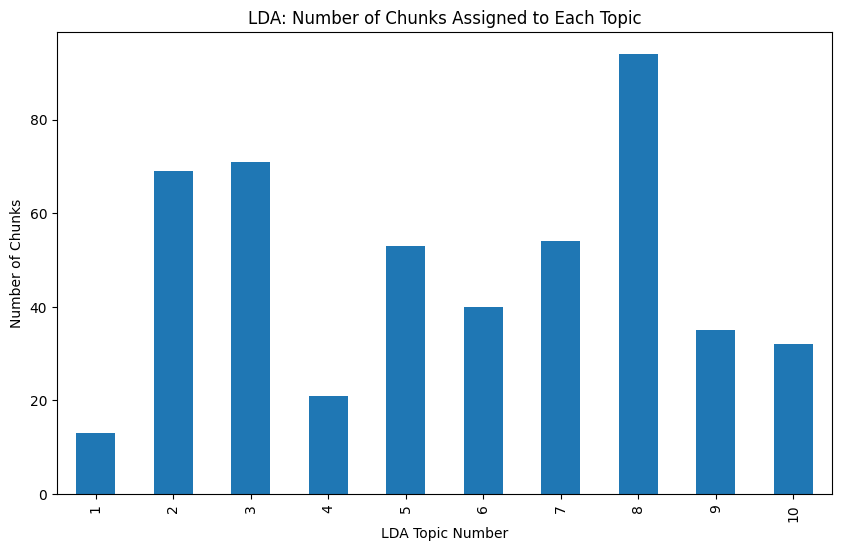

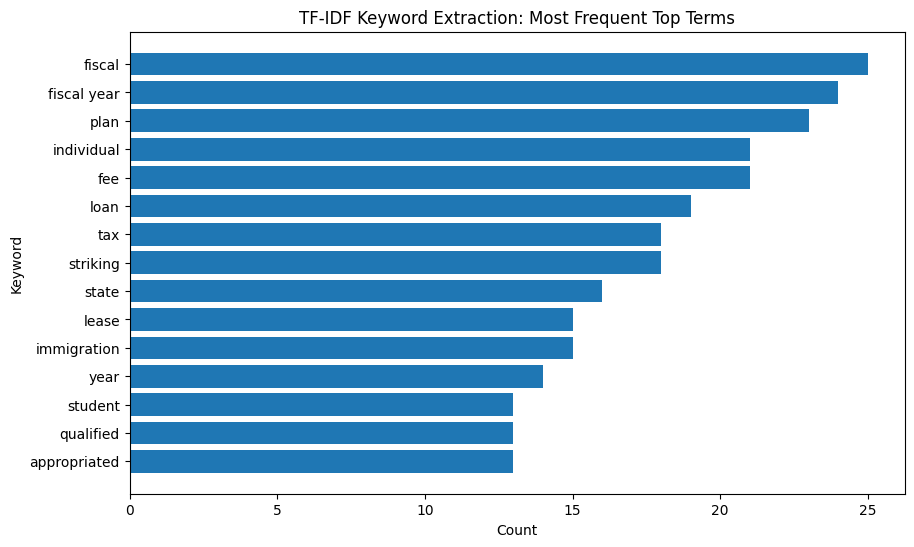


Saved:
 - hr1_topics_lda_keyword_results.csv
 - hr1_lda_topics.csv
 - hr1_keyword_summary.csv
 - hr1_keywords_by_section.csv
 - hr1_method_comparison_table.csv


In [2]:
#LDA Model Section

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation


# 1) Loading my cleaned up data
# =========================
df = pd.read_csv("hr1_topic_chunks.csv")

# Keeping only usable text rows
df = df[df["clean_text"].notna()].copy()
df["clean_text"] = df["clean_text"].astype(str).str.strip()
df = df[df["clean_text"].str.len() > 0].copy()

print("Rows loaded:", len(df))
print(df[["section_heading", "clean_text"]].head())



# 2) Doing the LDA topic modelling
# =========================
n_topics = 10  #I choose to do 10

lda_vectorizer = CountVectorizer( max_df=0.90, min_df=5, stop_words="english")

X_lda = lda_vectorizer.fit_transform(df["clean_text"])
lda_feature_names = lda_vectorizer.get_feature_names_out()

lda = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    learning_method="batch"
)

lda.fit(X_lda)

def print_lda_topics(model, feature_names, n_top_words=10):
    print("\n================ LDA TOPICS ================\n")
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(f"Topic {topic_idx+1}: {', '.join(top_words)}")

print_lda_topics(lda, lda_feature_names, n_top_words=10)


# Assign dominant LDA topic to each chunk
lda_topic_dist = lda.transform(X_lda)
df["lda_dominant_topic"] = lda_topic_dist.argmax(axis=1) + 1
df["lda_topic_prob"] = lda_topic_dist.max(axis=1)

print("\nLDA assignment sample:")
print(df[["section_heading", "lda_dominant_topic", "lda_topic_prob"]].head())



# 3) Saving the LDA topics table to look at later

lda_topic_rows = []

for topic_idx, topic in enumerate(lda.components_):
    top_word_indices = topic.argsort()[:-11:-1]
    top_words = [lda_feature_names[i] for i in top_word_indices]
    lda_topic_rows.append({
        "topic_number": topic_idx + 1,
        "top_words": ", ".join(top_words)
    })

lda_topics_df = pd.DataFrame(lda_topic_rows)

print("\nLDA topics table:")
print(lda_topics_df)



# 4) Just a basic TF-IDF KEYWORD EXTRACTION

tfidf_vectorizer = TfidfVectorizer(
    max_df=0.90,
    min_df=5,
    stop_words="english",
    ngram_range=(1, 3)   # includes single words, bigrams, trigrams
)

X_tfidf = tfidf_vectorizer.fit_transform(df["clean_text"])
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

def get_top_keywords(row_vector, feature_names, top_n=5):
    row_array = row_vector.toarray().flatten()
    top_indices = row_array.argsort()[-top_n:][::-1]
    top_terms = [feature_names[i] for i in top_indices if row_array[i] > 0]
    return top_terms

# Extract top keywords per chunk
df["keyword_terms"] = [
    get_top_keywords(X_tfidf[i], tfidf_feature_names, top_n=5)
    for i in range(X_tfidf.shape[0])
]

# Break them into columns for readability
for i in range(5):
    df[f"keyword_term_{i+1}"] = df["keyword_terms"].apply(
        lambda x: x[i] if len(x) > i else None
    )

print("\nKeyword extraction sample:")
print(df[[
    "section_heading",
    "keyword_term_1",
    "keyword_term_2",
    "keyword_term_3",
    "keyword_term_4",
    "keyword_term_5"
]].head())


#5) SUmmarizing the Keywords before doing my actual KeyBERT work later on
all_keywords = []

for terms in df["keyword_terms"]:
    all_keywords.extend(terms)

keyword_summary = (
    pd.Series(all_keywords)
    .value_counts()
    .reset_index()
)

keyword_summary.columns = ["keyword", "count"]

print("\nMost common extracted keywords:")
print(keyword_summary.head(20))


# 6) Just a summary on the keywords i pulled with the Tf-IDF

section_keyword_summary = (
    df.groupby("section_heading")[[
        "keyword_term_1",
        "keyword_term_2",
        "keyword_term_3",
        "keyword_term_4",
        "keyword_term_5"
    ]]
    .agg(lambda col: ", ".join([str(x) for x in col.dropna().head(5)]))
    .reset_index()
)

print("\nSection-level keyword summary sample:")
print(section_keyword_summary.head())


# 7) Vidualizaing with a bar graph the LDA topic


# ---- LDA topic counts ----
lda_counts = df["lda_dominant_topic"].value_counts().sort_index()

plt.figure(figsize=(10, 6))
lda_counts.plot(kind="bar")
plt.xlabel("LDA Topic Number")
plt.ylabel("Number of Chunks")
plt.title("LDA: Number of Chunks Assigned to Each Topic")
plt.show()


# The Top extracted keywords 
top_keywords_plot = keyword_summary.head(15).sort_values("count", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_keywords_plot["keyword"], top_keywords_plot["count"])
plt.xlabel("Count")
plt.ylabel("Keyword")
plt.title("TF-IDF Keyword Extraction: Most Frequent Top Terms")
plt.show()



# 9)Saving my outputs again(I have them commented out since i did them already)

#df.to_csv("hr1_topics_lda_keyword_results.csv", index=False)
#lda_topics_df.to_csv("hr1_lda_topics.csv", index=False)
#keyword_summary.to_csv("hr1_keyword_summary.csv", index=False)
#section_keyword_summary.to_csv("hr1_keywords_by_section.csv", index=False)
#comparison_table.to_csv("hr1_method_comparison_table.csv", index=False)

print("\nSaved:")
print(" - hr1_topics_lda_keyword_results.csv")
print(" - hr1_lda_topics.csv")
print(" - hr1_keyword_summary.csv")
print(" - hr1_keywords_by_section.csv")
print(" - hr1_method_comparison_table.csv")

In [4]:
#Looking into the actual probability distrubiton of the topics in the bar graph
import pandas as pd
import numpy as np
from collections import Counter

# Counting out chunks per LDA topic
lda_topic_counts = df["lda_dominant_topic"].value_counts().sort_index()

print("LDA topic counts:")
print(lda_topic_counts)

# this shows a Normalized distribution
lda_topic_distribution = df["lda_dominant_topic"].value_counts(normalize=True).sort_index()
print("\nLDA topic distribution:")
print(lda_topic_distribution)

LDA topic counts:
lda_dominant_topic
1     13
2     69
3     71
4     21
5     53
6     40
7     54
8     94
9     35
10    32
Name: count, dtype: int64

LDA topic distribution:
lda_dominant_topic
1     0.026971
2     0.143154
3     0.147303
4     0.043568
5     0.109959
6     0.082988
7     0.112033
8     0.195021
9     0.072614
10    0.066390
Name: proportion, dtype: float64


In [5]:
#Doign the same for the basic TF-IDF keywords before running the KeyBert Model
all_keywords = []
for terms in df["keyword_terms"]:
    all_keywords.extend(terms)

keyword_counts = pd.Series(all_keywords).value_counts()

print("Top repeated TF-IDF keywords:")
print(keyword_counts.head(20))
print("\nNumber of unique extracted keywords:", keyword_counts.index.nunique())

Top repeated TF-IDF keywords:
fiscal          25
fiscal year     24
plan            23
fee             21
individual      21
loan            19
striking        18
tax             18
state           16
immigration     15
lease           15
year            14
appropriated    13
qualified       13
student         13
foreign         13
inserting       12
child           12
energy          12
available       12
Name: count, dtype: int64

Number of unique extracted keywords: 1002


In [10]:
#!pip install --user tf-keras
#!pip install --user "transformers<4.40" "sentence-transformers<3.0"
#!pip install --user keybert
#!pip install --user --upgrade numpy
#!pip install --user --upgrade torch sentence-transformers keybert

  Using cached transformers-4.39.3-py3-none-any.whl (8.8 MB)
  Using cached sentence_transformers-2.7.0-py3-none-any.whl (171 kB)
  Using cached tokenizers-0.15.2-cp39-none-win_amd64.whl (2.2 MB)
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 4.57.6
    Uninstalling transformers-4.57.6:
      Successfully uninstalled transformers-4.57.6
  Attempting uninstall: sentence-transformers
    Found existing installation: sentence-transformers 5.1.2
    Uninstalling sentence-transformers-5.1.2:
      Successfully uninstalled sentence-transformers-5.1.2


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


  Using cached sentence_transformers-5.1.2-py3-none-any.whl (488 kB)
  Using cached transformers-4.57.6-py3-none-any.whl (12.0 MB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl (2.7 MB)
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.15.2
    Uninstalling tokenizers-0.15.2:
      Successfully uninstalled tokenizers-0.15.2
  Attempting uninstall: transformers
    Found existing installation: transformers 4.39.3
    Uninstalling transformers-4.39.3:
      Successfully uninstalled transformers-4.39.3
  Attempting uninstall: sentence-transformers
    Found existing installation: sentence-transformers 2.7.0
    Uninstalling sentence-transformers-2.7.0:
      Successfully uninstalled sentence-transformers-2.7.0


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [5]:

# Doing Model 2: KeyBERT


import pandas as pd
from keybert import KeyBERT
import re


# 1)Loading the cleaned Data

df = pd.read_csv("hr1_topic_chunks.csv")

df = df[df["clean_text"].notna()].copy()
df["clean_text"] = df["clean_text"].astype(str).str.strip()
df = df[df["clean_text"] != ""].copy()

print("Rows loaded:", len(df))



# 2) My Larger list of legal stop words to account for KeyBERT sensitvity

LEGAL_STOPWORDS = {
    "act", "section", "subsection", "paragraph", "subparagraph", "clause",
    "title", "subtitle", "part", "subpart",
    "secretary", "administrator",
    "shall", "may", "including", "include",
    "insert", "inserting", "strike", "striking",
    "amend", "amended", "amendment",
    "following", "date", "general", "term", "respect",
    "applicable", "enactment", "years", "year",
    "thereof", "herein", "provided", "provides",
    "means", "definition", "defined"
}


# 3) Cleaning the text again

def clean_for_keybert(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    
    tokens = [
        tok for tok in text.split()
        if len(tok) > 2 and tok not in LEGAL_STOPWORDS
    ]
    
    return " ".join(tokens)

df["kb_clean_text"] = df["clean_text"].apply(clean_for_keybert)

print("\nCleaned text sample:")
print(df[["section_heading", "kb_clean_text"]].head())


# 4)Loading the KeyBert model

kw_model = KeyBERT(model="all-MiniLM-L6-v2")



# 5)Doing Batch keyword extraction

texts = df["kb_clean_text"].tolist()

print("Running KeyBERT with cleaned text...")

keybert_results = kw_model.extract_keywords(
    texts,
    keyphrase_ngram_range=(1, 3),
    stop_words="english",
    use_maxsum=True,
    nr_candidates=20,
    top_n=5
)

df["keybert_results"] = keybert_results

print("Done.")

# 6) splitting my results into coloumns

for i in range(5):
    df[f"kb_term_{i+1}"] = df["keybert_results"].apply(
        lambda x: x[i][0] if len(x) > i else None
    )
    df[f"kb_score_{i+1}"] = df["keybert_results"].apply(
        lambda x: x[i][1] if len(x) > i else None
    )

print("\nSample cleaned KeyBERT output:")
print(df[["section_heading", "kb_term_1", "kb_term_2", "kb_term_3"]].head())


# 7) The summary of my results(the top 20 keywords)

top_terms = df["kb_term_1"].dropna().tolist()

keybert_summary = (
    pd.Series(top_terms)
    .value_counts()
    .reset_index()
)

keybert_summary.columns = ["keyword", "count"]

print("\nTop cleaned KeyBERT keywords:")
print(keybert_summary.head(20))



# 8) Finally saving all of my results

df.to_csv("hr1_keybert_cleaned_results.csv", index=False)
keybert_summary.to_csv("hr1_keybert_cleaned_summary.csv", index=False)

print("\nSaved cleaned results.")

Rows loaded: 482

Cleaned text sample:
  section_heading                                      kb_clean_text
0     SEC. 10001.  thrifty food plan food nutrition read follows ...
1     SEC. 10002.  able bodied adults dependents work requirement...
2     SEC. 10003.  able bodied adults dependents waivers food nut...
3     SEC. 10004.  availability standard utility allow ances base...
4     SEC. 10005.  restrictions internet expenses food nutrition ...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Running KeyBERT with cleaned text...
Done.

Sample cleaned KeyBERT output:
  section_heading               kb_term_1                    kb_term_2  \
0     SEC. 10001.        food urban rural        food composition data   
1     SEC. 10002.        unfit employment        individual compliance   
2     SEC. 10003.      able bodied adults  determination county county   
3     SEC. 10004.  member households hird               receipt energy   
4     SEC. 10005.      modem rentals fees                 restrictions   

                     kb_term_3  
0          plan food nutrition  
1                bodied adults  
2         state agency support  
3          utility allow ances  
4  estrictions internet penses  

Top cleaned KeyBERT keywords:
                          keyword  count
0           specified fiscal rule      3
1            effect day rescinded      3
2   escission unobligated balance      3
3    treasury appropriated remain      3
4           internal revenue code      2
5    

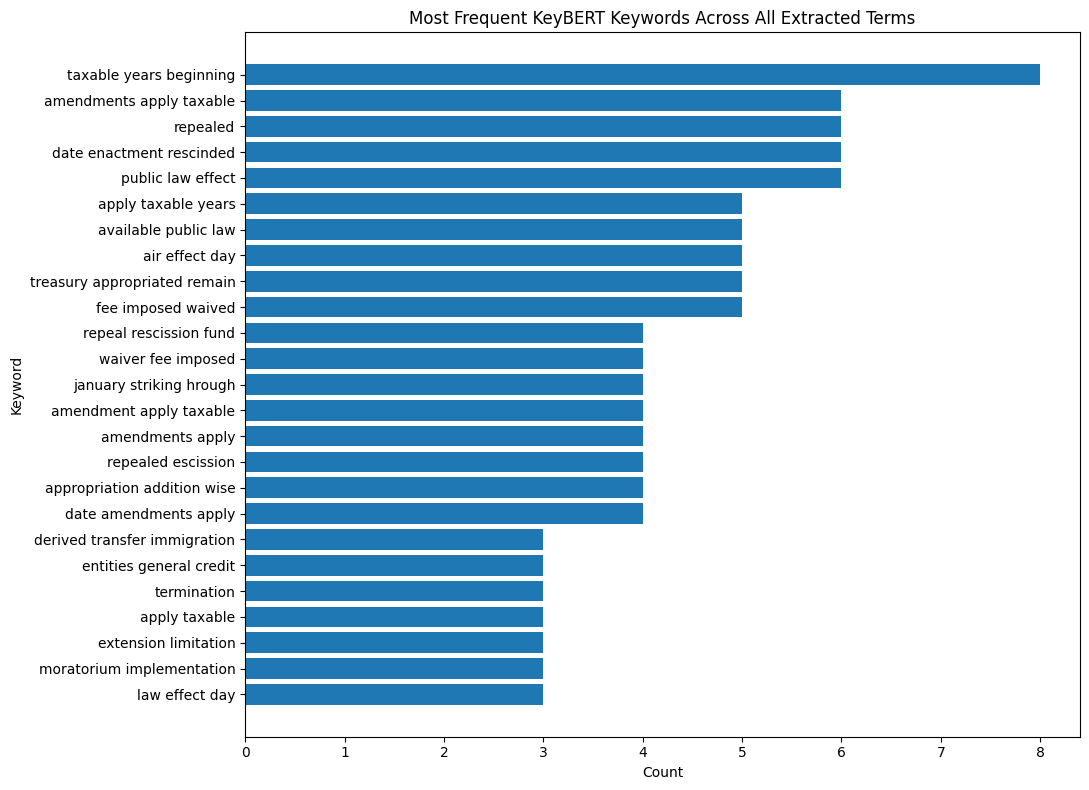

In [3]:
#Then I can finally look into the actual keyword terms and look at the most frequenct terms across everything that was extracted this is what I ultimaetly looked at 
all_kb_terms = []

for col in ["kb_term_1", "kb_term_2", "kb_term_3", "kb_term_4", "kb_term_5"]:
    all_kb_terms.extend(df[col].dropna().tolist())

all_terms_summary = (
    pd.Series(all_kb_terms)
    .value_counts()
    .reset_index()
)
all_terms_summary.columns = ["keyword", "count"]

top_n = 25
plot_df2 = all_terms_summary.head(top_n).sort_values("count", ascending=True)

plt.figure(figsize=(11, 8))
plt.barh(plot_df2["keyword"], plot_df2["count"])
plt.xlabel("Count")
plt.ylabel("Keyword")
plt.title("Most Frequent KeyBERT Keywords Across All Extracted Terms")
plt.tight_layout()
plt.show()